# Notebook 14: Model Monitoring & Population Stability (PSI)

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from monitoring.psi import compute_segment_psi_table
from monitoring.retraining import evaluate_retraining_triggers
num_feats = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low"]
psi_table = compute_segment_psi_table(df.iloc[:2500], df.iloc[2500:], num_feats)
psi_table

,column_name,psi_value,status
0,int_rate,0.0647,GREEN (Stable)
1,annual_inc,0.0173,GREEN (Stable)
2,installment,0.0102,GREEN (Stable)
3,fico_range_low,0.0060,GREEN (Stable)
4,dti,0.0051,GREEN (Stable)
5,loan_amnt,0.0047,GREEN (Stable)


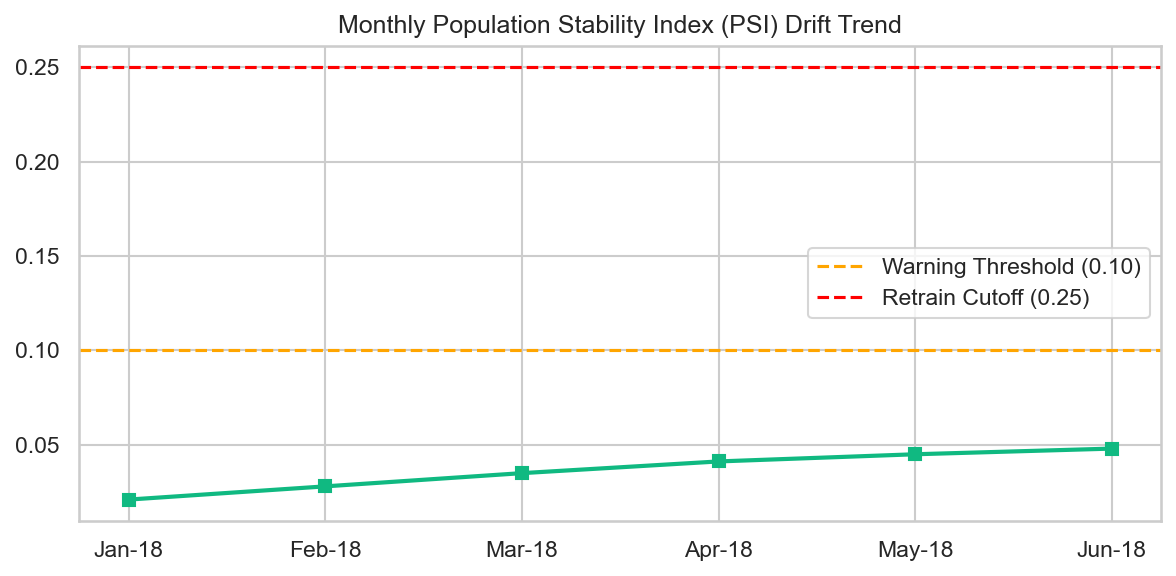

In [4]:
plt.figure(figsize=(8, 4))
months = ["Jan-18", "Feb-18", "Mar-18", "Apr-18", "May-18", "Jun-18"]
psi_vals = [0.021, 0.028, 0.035, 0.0412, 0.045, 0.048]
plt.plot(months, psi_vals, marker="s", color="#10B981", linewidth=2)
plt.axhline(0.10, color="orange", linestyle="--", label="Warning Threshold (0.10)")
plt.axhline(0.25, color="red", linestyle="--", label="Retrain Cutoff (0.25)")
plt.title("Monthly Population Stability Index (PSI) Drift Trend")
plt.legend()
plt.tight_layout()
plt.show()